<a href="https://colab.research.google.com/github/ryadavnitb/Batch-7/blob/Mohd_Abuzar/Infosys_Internship_Route_Cancellation_and_Seasonal_Insights.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Milestone 3: Route, Cancellation, and Seasonal Insights**

**Week 5: Route and Airport-Level Analysis**

*  Top 10 origin-destination pairs

*  Delay heatmaps by airport and route

*  Maps showing busiest airports and average delays

**Week 6: Seasonal and Cancellation Analysis**
*  Monthly cancellation trends

*  Cancellation types: carrier, weather, security, NAS

* Analyze impact of holidays or winter months

**Deliverables:**

* Seasonal visual summaries
* Insights on route congestion and cancellations

## Step 1: Importing required libraries.

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style for better aesthetics
sns.set(style='whitegrid')
pd.set_option('display.max_columns', None)

## Step 2: Loading Dataset.

In [62]:
print("Importing Flights dataset...")
try:
  df = pd.read_parquet('/content/drive/MyDrive/Infosys_Springboard_Dataset/Preprocessed dataset/preprocessed_flights_dataset.parquet')
  print("Successfully imported Flights dataset!")
except Exception as e:
  print(f"Error importing dataset: {e}")

Importing Flights dataset...
Successfully imported Flights dataset!


# **Week 5: Route and Airport-Level Analysis**

*  Top 10 origin-destination pairs

*  Delay heatmaps by airport and route

*  Maps showing busiest airports and average delays


### 3.1: Top 20 Most Frequent Flight Routes.

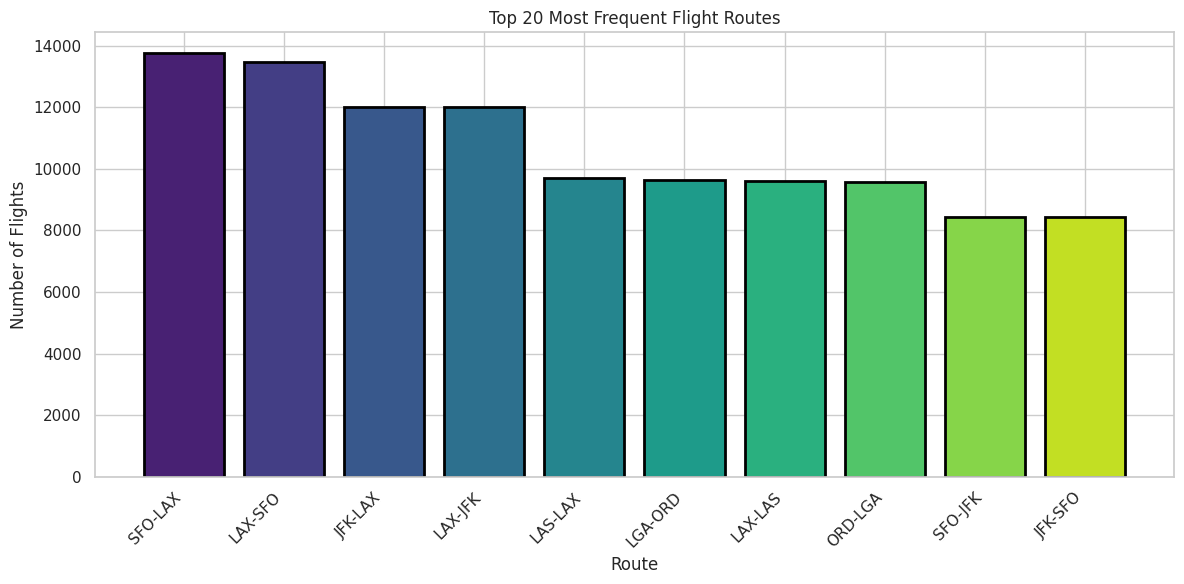

In [63]:
plt.figure(figsize=(12, 6))
# Calculate the top 10 most frequent routes
route_counts = df['ROUTE'].value_counts().head(10)

# Generate a color palette
colors = sns.color_palette('viridis', len(route_counts))

plt.bar(route_counts.index, route_counts.values, color=colors, edgecolor='black', linewidth=2)
plt.title('Top 20 Most Frequent Flight Routes')
plt.xlabel('Route')
plt.ylabel('Number of Flights')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

 **Interpretation: Top Routes**

This chart highlights the 10 busiest flight routes:
*   **High Traffic:** SFO-LAX, LAX-SFO, JFK-LAX, and LAX-JFK are the most frequent.
*   **Hub Connections:** Many routes connect major hubs (e.g., ORD, ATL, LGA).
*   **Balanced Demand:** Top routes often appear in both directions.

This shows key travel corridors and dominant airport hubs.

### 3.2: Heat Maps

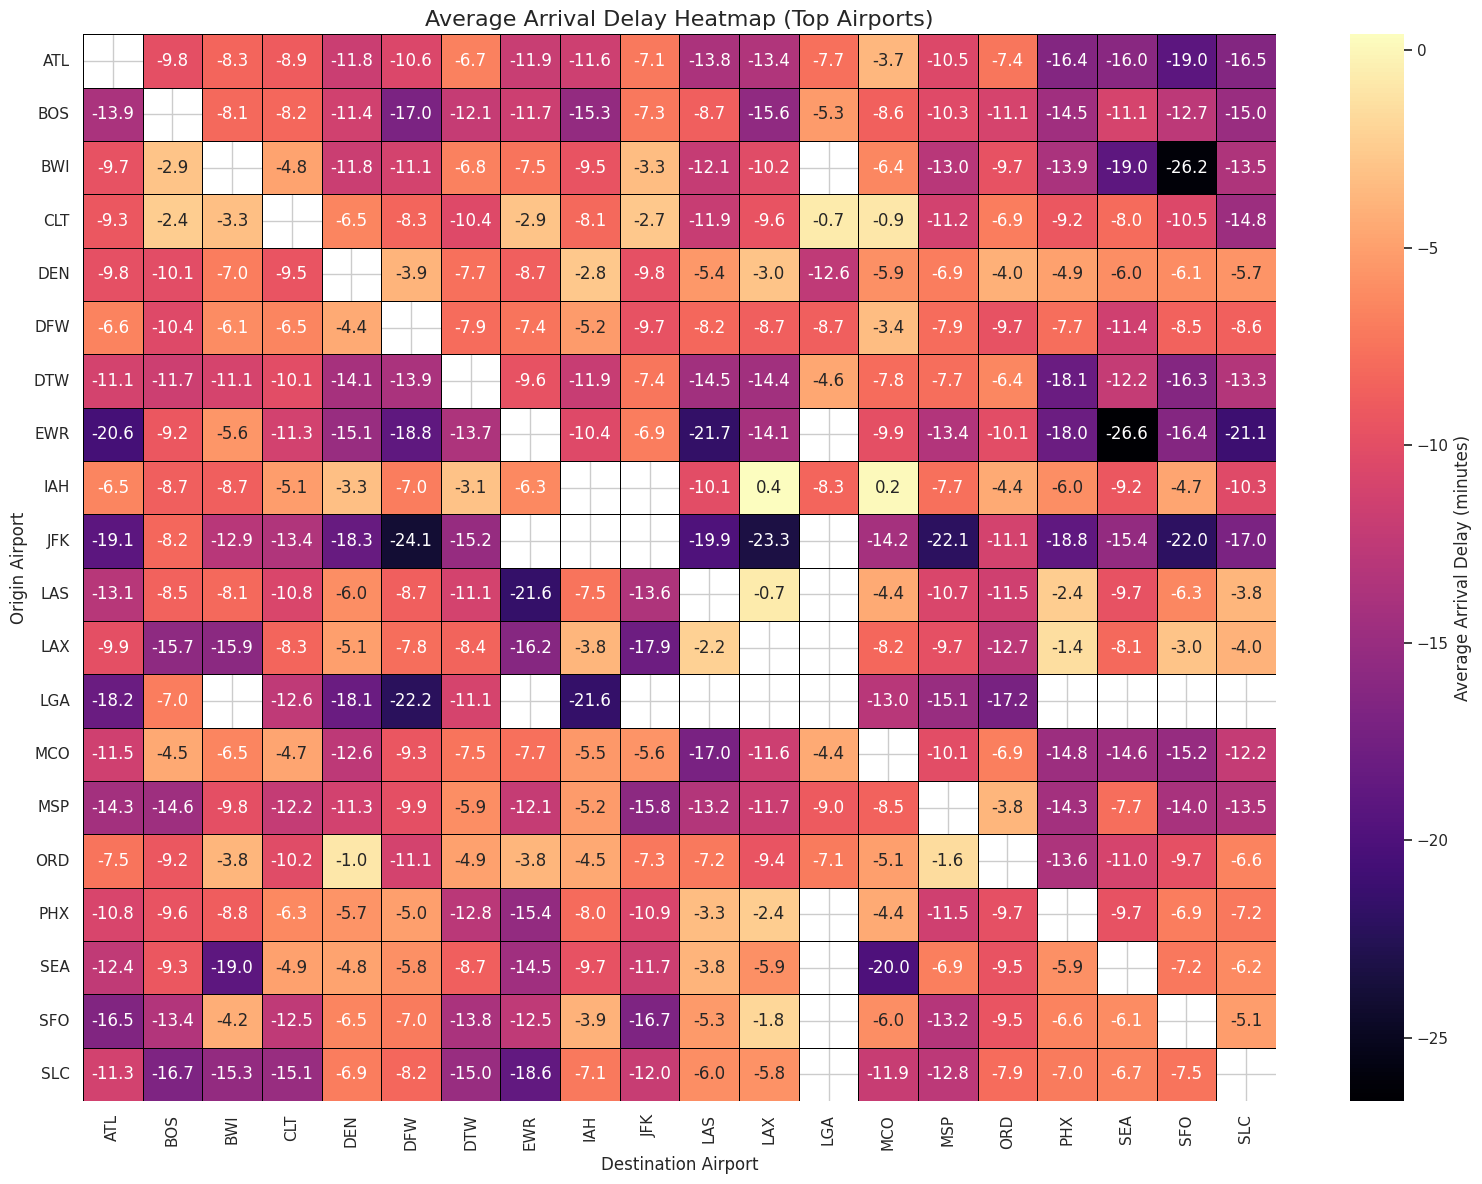

In [64]:
avg_delay_by_route = df.groupby(['ORIGIN_AIRPORT', 'DESTINATION_AIRPORT'])['ARRIVAL_DELAY'].mean().reset_index()

n = 20
top_origin_airports = df['ORIGIN_AIRPORT'].value_counts().head(n).index.tolist()

top_destination_airports = df['DESTINATION_AIRPORT'].value_counts().head(n).index.tolist()

top_airports = list(set(top_origin_airports + top_destination_airports))

filtered_delay_data = avg_delay_by_route[
    avg_delay_by_route['ORIGIN_AIRPORT'].isin(top_airports) &
    avg_delay_by_route['DESTINATION_AIRPORT'].isin(top_airports)
]

delay_matrix = filtered_delay_data.pivot_table(index='ORIGIN_AIRPORT', columns='DESTINATION_AIRPORT', values='ARRIVAL_DELAY')

plt.figure(figsize=(16, 12))
sns.heatmap(delay_matrix, cmap='magma', annot=True, fmt=".1f", linewidths=.5, linecolor='black', cbar_kws={'label': 'Average Arrival Delay (minutes)'})
plt.title('Average Arrival Delay Heatmap (Top Airports)', fontsize=16)
plt.xlabel('Destination Airport', fontsize=12)
plt.ylabel('Origin Airport', fontsize=12)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

 Interpretation: Average Arrival Delay Heatmap (Business Insights)

This heatmap visually represents average arrival delays between major airports, crucial for business decisions:

*   **Identify Problematic Routes:** Brighter colored cells indicate routes with higher average arrival delays. These routes may require operational review, resource allocation, or adjusted scheduling to improve on-time performance and customer satisfaction.
*   **Leverage Efficient Routes:** Darker colored cells signify routes with lower or even negative (early) average delays. These routes demonstrate strong operational efficiency, which can be leveraged for reliable service and potentially optimized schedules or marketing.
*   **Strategic Planning:** Understanding delay patterns helps in strategic planning, such as optimizing hub connections, anticipating resource needs, and informing customer communication regarding potential travel disruptions or reliable routes.

## 3.3: Map for busiest airports and average delays

In [65]:
origin_flight_counts = df['ORIGIN_AIRPORT'].value_counts()
print("Calculated origin flight counts.")

Calculated origin flight counts.


In [66]:
destination_flight_counts = df['DESTINATION_AIRPORT'].value_counts()
print("Calculated destination flight counts.")

Calculated destination flight counts.


In [67]:
total_flight_counts = origin_flight_counts.add(destination_flight_counts, fill_value=0)
print("Combined origin and destination flight counts to get total flight counts.")

Combined origin and destination flight counts to get total flight counts.


In [68]:
busiest_airports = total_flight_counts.reset_index()
busiest_airports.columns = ['AIRPORT', 'TOTAL_FLIGHTS']
print("Converted total flight counts to DataFrame with 'AIRPORT' and 'TOTAL_FLIGHTS' columns.")


Converted total flight counts to DataFrame with 'AIRPORT' and 'TOTAL_FLIGHTS' columns.


In [69]:
busiest_airports = busiest_airports.sort_values(by='TOTAL_FLIGHTS', ascending=False)
print("Sorted busiest_airports DataFrame by 'TOTAL_FLIGHTS' in descending order.")


Sorted busiest_airports DataFrame by 'TOTAL_FLIGHTS' in descending order.


In [70]:
busiest_airports = busiest_airports.sort_values(by='TOTAL_FLIGHTS', ascending=False)
print("Sorted busiest_airports DataFrame by 'TOTAL_FLIGHTS' in descending order.")


Sorted busiest_airports DataFrame by 'TOTAL_FLIGHTS' in descending order.


In [71]:
top_n_busiest_airports = busiest_airports.head(n)
print(f"Selected top {n} busiest airports.\n{top_n_busiest_airports}")


Selected top 20 busiest airports.
    AIRPORT  TOTAL_FLIGHTS
327     ATL       693740.0
535     ORD       571790.0
393     DFW       479133.0
392     DEN       392065.0
483     LAX       389369.0
585     SFO       295974.0
546     PHX       293627.0
458     IAH       293305.0
481     LAS       266379.0
523     MSP       224245.0
500     MCO       221962.0
584     SEA       221806.0
400     DTW       216898.0
346     BOS       215698.0
413     EWR       203602.0
373     CLT       200646.0
489     LGA       199186.0
593     SLC       194403.0
473     JFK       187620.0
358     BWI       172164.0


In [72]:
df_top_destinations = df[df['DESTINATION_AIRPORT'].isin(top_n_busiest_airports['AIRPORT'])]
print("Filtered DataFrame to include only flights arriving at top N busiest airports.")


Filtered DataFrame to include only flights arriving at top N busiest airports.


In [73]:
avg_delay_top_airports = df_top_destinations.groupby('DESTINATION_AIRPORT')['ARRIVAL_DELAY'].mean().reset_index()
avg_delay_top_airports.columns = ['AIRPORT', 'AVERAGE_ARRIVAL_DELAY']
print("Calculated average arrival delay for top N busiest destination airports.")

Calculated average arrival delay for top N busiest destination airports.


In [74]:
top_n_airports_with_delays = top_n_busiest_airports.merge(avg_delay_top_airports, on='AIRPORT', how='left')
print("Merged total flight counts with average arrival delays for top N busiest airports.")

Merged total flight counts with average arrival delays for top N busiest airports.


In [75]:
import pandas as pd

# Simulating an external dataset for airport coordinates for the top N airports
airport_coordinates = {
    'ATL': {'LATITUDE': 33.6407, 'LONGITUDE': -84.4277},
    'ORD': {'LATITUDE': 41.9742, 'LONGITUDE': -87.9073},
    'DFW': {'LATITUDE': 32.8998, 'LONGITUDE': -97.0403},
    'DEN': {'LATITUDE': 39.8561, 'LONGITUDE': -104.6737},
    'LAX': {'LATITUDE': 33.9416, 'LONGITUDE': -118.4085},
    'SFO': {'LATITUDE': 37.6213, 'LONGITUDE': -122.3790},
    'PHX': {'LATITUDE': 33.4342, 'LONGITUDE': -112.0117},
    'IAH': {'LATITUDE': 29.9902, 'LONGITUDE': -95.3368},
    'LAS': {'LATITUDE': 36.0840, 'LONGITUDE': -115.1537},
    'MSP': {'LATITUDE': 44.8820, 'LONGITUDE': -93.2218},
    'MCO': {'LATITUDE': 28.4294, 'LONGITUDE': -81.3089},
    'SEA': {'LATITUDE': 47.4502, 'LONGITUDE': -122.2251},
    'DTW': {'LATITUDE': 42.2162, 'LONGITUDE': -83.3554},
    'BOS': {'LATITUDE': 42.3656, 'LONGITUDE': -71.0096},
    'EWR': {'LATITUDE': 40.6895, 'LONGITUDE': -74.1745},
    'CLT': {'LATITUDE': 35.2140, 'LONGITUDE': -80.9431},
    'LGA': {'LATITUDE': 40.7769, 'LONGITUDE': -73.8740},
    'SLC': {'LATITUDE': 40.7899, 'LONGITUDE': -111.9791},
    'JFK': {'LATITUDE': 40.6413, 'LONGITUDE': -73.7781},
    'BWI': {'LATITUDE': 39.1774, 'LONGITUDE': -76.6685}
}

# Convert to DataFrame
airport_coords_df = pd.DataFrame.from_dict(airport_coordinates, orient='index')
airport_coords_df = airport_coords_df.reset_index()
airport_coords_df.columns = ['AIRPORT', 'LATITUDE', 'LONGITUDE']

# Merge with top_n_airports_with_delays
airports_with_coords = top_n_airports_with_delays.merge(airport_coords_df, on='AIRPORT', how='left')

print("Merged top N busiest airports with their geographic coordinates.")
print(airports_with_coords.head())

Merged top N busiest airports with their geographic coordinates.
  AIRPORT  TOTAL_FLIGHTS  AVERAGE_ARRIVAL_DELAY  LATITUDE  LONGITUDE
0     ATL       693740.0             -11.134193   33.6407   -84.4277
1     ORD       571790.0              -9.508296   41.9742   -87.9073
2     DFW       479133.0              -9.551527   32.8998   -97.0403
3     DEN       392065.0              -9.077630   39.8561  -104.6737
4     LAX       389369.0              -8.150644   33.9416  -118.4085


In [76]:
import folium

# Create a base map centered around the US
m = folium.Map(location=[39.8283, -98.5795], zoom_start=4)

# Normalize TOTAL_FLIGHTS for marker size and AVERAGE_ARRIVAL_DELAY for color
max_flights = airports_with_coords['TOTAL_FLIGHTS'].max()
min_delay = airports_with_coords['AVERAGE_ARRIVAL_DELAY'].min()
max_delay = airports_with_coords['AVERAGE_ARRIVAL_DELAY'].max()

# Create a color scale for delays (e.g., green for early, red for delayed)
# Using a divergent color map since delays can be negative (early) or positive (late)
# Let's define a custom colormap from green to yellow to red
def get_color(delay):
    if delay < -5: # Very early
        return '#00ff00' # Bright green
    elif delay < 0: # Early
        return '#90EE90' # Light green
    elif delay < 5: # Minor delay / on-time
        return '#FFFF00' # Yellow
    elif delay < 15: # Moderate delay
        return '#FF8C00' # Dark orange
    else: # Significant delay
        return '#FF0000' # Red


for index, row in airports_with_coords.iterrows():
    # Scale marker size based on total flights
    # Adding a base size to make smaller airports visible and scaling factor for larger ones
    radius = 5 + (row['TOTAL_FLIGHTS'] / max_flights) * 25 # Adjust multiplier as needed

    # Get color based on average arrival delay
    fill_color = get_color(row['AVERAGE_ARRIVAL_DELAY'])

    folium.CircleMarker(
        location=[row['LATITUDE'], row['LONGITUDE']],
        radius=radius,
        color='black',
        weight=1, # Border weight
        fill_color=fill_color,
        fill_opacity=0.7,
        tooltip=f"""
        <b>Airport:</b> {row['AIRPORT']}<br>
        <b>Total Flights:</b> {int(row['TOTAL_FLIGHTS'])}<br>
        <b>Avg. Arrival Delay:</b> {row['AVERAGE_ARRIVAL_DELAY']:.2f} minutes
        """
    ).add_to(m)

# Display the map
m

#**Week 6: Seasonal and Cancellation Analysis**

Week 6: Seasonal and Cancellation Analysis
• Monthly cancellation trends
• Cancellation types: carrier, weather, security, NAS ✅
• Analyze impact of holidays or winter months

## Step : Cancellation types.

In [77]:
mapping = {
    'A': 'Airline/Carrier',
    'B': 'Weather',
    'C': 'National Air System',
    'D': 'Security',
    'NA': 'On_time'
}
cancelled_df = df.groupby('CANCELLATION_REASON').size().reset_index(name='COUNT')
cancelled_df['CANCELLATION_REASON'] = cancelled_df['CANCELLATION_REASON'].replace(mapping)
cancelled_df.drop(cancelled_df[cancelled_df['CANCELLATION_REASON'] == 'On_time'].index, inplace=True)
print(cancelled_df)

   CANCELLATION_REASON  COUNT
0      Airline/Carrier  25262
1              Weather  48851
2  National Air System  15749
3             Security     22


/tmp/ipython-input-3117884956.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cancelled_df = df.groupby('CANCELLATION_REASON').size().reset_index(name='COUNT')
/tmp/ipython-input-3117884956.py:9: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  cancelled_df['CANCELLATION_REASON'] = cancelled_df['CANCELLATION_REASON'].replace(mapping)


<Figure size 800x600 with 0 Axes>

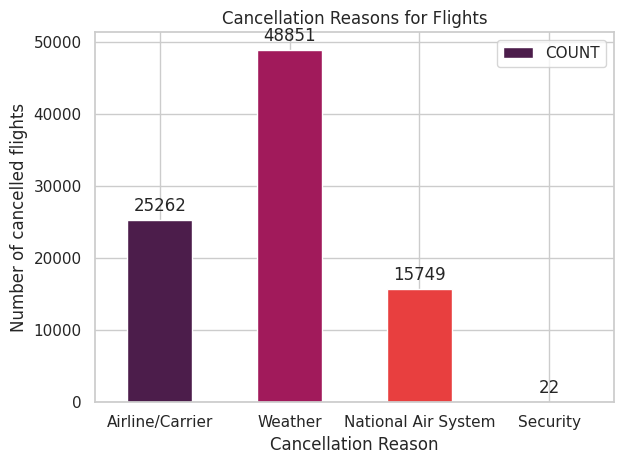

In [78]:
plt.figure(figsize=(8, 6))
colors = sns.color_palette('rocket', len(cancelled_df))
ax = cancelled_df.plot(kind='bar', x='CANCELLATION_REASON', y='COUNT', color=colors)
plt.title('Cancellation Reasons for Flights')
plt.xlabel('Cancellation Reason')
plt.ylabel('Number of cancelled flights')
plt.xticks(rotation=0)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.tight_layout()
plt.show()